<a href="https://colab.research.google.com/github/otavioolimpio/lego-cv-checker/blob/main/Lego_CV_Checker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Projeto de Visão Computacional para Validação de Kits LEGO

Este projeto implementa um sistema de visão computacional para automatizar a contagem e validação de peças LEGO. O processo é dividido em várias etapas, desde a configuração do repositório de peças até a análise final da imagem.

## Etapas do Processo:

1.  **Configuração do Inventário Gabarito e Interface de Seleção**: Define o banco de dados das peças LEGO e permite a seleção da peça-alvo.
2.  **Carregamento da Imagem e Segmentação por Cor (Espaço HSV)**: Carrega a imagem da mesa com as peças e isola a peça-alvo pela sua cor.
3.  **Morfologia Matemática (Tratamento de Ruídos e Falhas)**: Limpa a imagem binária, preenchendo buracos e removendo ruídos.
4.  **Extração de Contornos e Filtragem Geométrica Proporcional**: Identifica os objetos na imagem limpa e os filtra com base em sua área proporcional.
5.  **Validação do Kit e Exibição do Resultado Visual Final**: Calcula o saldo de peças, desenha caixas delimitadoras e apresenta o veredito final do kit.

In [6]:
# ==============================================================================
# ETAPA 1: CONFIGURAÇÃO DO INVENTÁRIO (GABARITO) E INTERFACE DE SELEÇÃO
# ==============================================================================
# Esta célula define o banco de dados oficial do Kit Lego baseado no manual.
# Também cria um menu interativo (Form) para selecionar a peça alvo.
# ==============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Associamos o nome exato de cada peça à sua cor e à quantidade total do kit.
gabarito_kit_lego = {
    "cross_axle_2m_red":       {"cor": "vermelho", "qtd_esperada": 8},
    "wire_clip_cross_red":     {"cor": "vermelho", "qtd_esperada": 2},
    "brick_2x4_red":           {"cor": "vermelho", "qtd_esperada": 2},

    "wire_clip_cross_green":   {"cor": "verde",    "qtd_esperada": 2},
    "brick_2x4_green":         {"cor": "verde",    "qtd_esperada": 2},

    "wire_clip_cross_magenta": {"cor": "magenta",  "qtd_esperada": 2},
    "technic_5m_beam_magenta": {"cor": "magenta",  "qtd_esperada": 4},
    "technic_11m_beam_magenta":{"cor": "magenta",  "qtd_esperada": 4},
    "biscuit_1x3x3_magenta":   {"cor": "magenta",  "qtd_esperada": 6},
    "brick_2x4_magenta":       {"cor": "magenta",  "qtd_esperada": 2}
}

#@markdown ### Selecione o modelo de peça Lego que deseja conferir na imagem:
peca_selecionada = "brick_2x4_green" #@param ["cross_axle_2m_red", "wire_clip_cross_red", "brick_2x4_red", "wire_clip_cross_green", "brick_2x4_green", "wire_clip_cross_magenta", "technic_5m_beam_magenta", "technic_11m_beam_magenta", "biscuit_1x3x3_magenta", "brick_2x4_magenta"]

# O programa busca no dicionário os parâmetros necessários para as próximas etapas.
dados_alvo = gabarito_kit_lego[peca_selecionada]
cor_alvo = dados_alvo["cor"]
quantidade_alvo = dados_alvo["qtd_esperada"]

# Exibição dos dados para o usuário confirmar o alvo
print("=" * 65)
print(f" CONFIGURAÇÃO DO ALVO ATUALIZADA COM SUCESSO:")
print(f" -> Peça selecionada: {peca_selecionada}")
print(f" -> Cor a ser filtrada: {cor_alvo.upper()}")
print(f" -> Quantidade exigida no kit: {quantidade_alvo} unidades")
print("=" * 65)

 CONFIGURAÇÃO DO ALVO ATUALIZADA COM SUCESSO:
 -> Peça selecionada: brick_2x4_green
 -> Cor a ser filtrada: VERDE
 -> Quantidade exigida no kit: 2 unidades


In [7]:
from google.colab import files
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Clique no botão abaixo para submeter a imagem


Saving Brick 2x4 green.jfif to Brick 2x4 green.jfif
Arquivo recebido com sucesso!


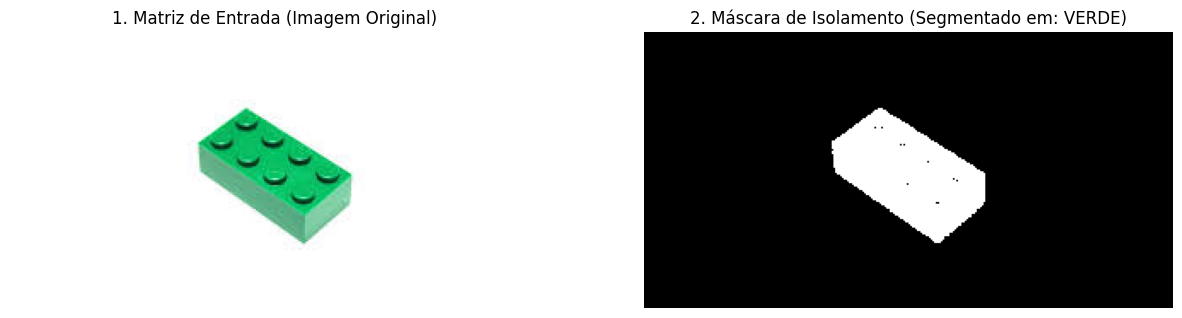

In [8]:
# ==============================================================================
# ETAPA 2: CARREGAMENTO DA IMAGEM E SEGMENTAÇÃO POR COR (ESPAÇO HSV)
# ==============================================================================
# Esta célula automatiza a recepção de qualquer arquivo JPEG/JPG, converte-o
# para o domínio do HSV e cria uma máscara binária baseada na cor da peça-alvo.
# ==============================================================================

from google.colab import files
import os

# 1. ENTRADA DE DADOS (UPLOAD DO ARQUIVO JPEG)
# Abre o gerenciador de arquivos nativo do sistema operacional do usuário
print("Clique no botão abaixo para submeter a imagem")
uploaded = files.upload()

# Validação de segurança caso o usuário feche a janela sem selecionar um arquivo
if not uploaded:
    print("Erro de Execução: Nenhum arquivo foi submetido.")
else:
    # Captura de forma dinâmica o nome do arquivo que foi enviado para a memória
    nome_arquivo = list(uploaded.keys())[0]
    print(f"Arquivo recebido com sucesso!")

    # 2. LEITURA DA IMAGEM EM MATRIZ NUMÉRICA (OPENCV)
    # Por padrão de engenharia do OpenCV, a imagem é lida no formato matricial BGR
    img_original = cv2.imread(nome_arquivo)

    # 3. TRANSLADO DE DOMÍNIO DE CORES: BGR ➔ HSV
    # Esta conversão separa a cor pura (H) da quantidade de branco (S) e de preto (V)
    img_hsv = cv2.cvtColor(img_original, cv2.COLOR_BGR2HSV)

    # 4. DICIONÁRIO DE PARAMETRIZAÇÃO DAS MÁSCARAS CRÍTICAS (LIMITES HSV)
    # Calibração de bandas para mitigar variações de iluminação.
    # Canal H (0-180), Canal S (0-255), Canal V (0-255).
    limites_hsv = {
        "vermelho": {
            # O vermelho ocupa as duas extremidades do canal H (perto de 0 e perto de 180)
            "inf_1": np.array([0, 70, 50]),
            "sup_1": np.array([12, 255, 255]),
            "inf_2": np.array([165, 70, 50]),
            "sup_2": np.array([180, 255, 255])
        },
        "verde": {
            "inf": np.array([35, 40, 40]),
            "sup": np.array([90, 255, 255])
        },
        "magenta": {
            "inf": np.array([130, 40, 40]),
            "sup": np.array([165, 255, 255])
        }
    }

    # 5. CONSTRUÇÃO DA MÁSCARA BINÁRIA
    # O algoritmo busca a string 'cor_alvo' definida no dicionário
    if cor_alvo == "vermelho":
        # Processamento de banda dupla para o espectro do vermelho
        mascara_vermelho_1 = cv2.inRange(img_hsv, limites_hsv["vermelho"]["inf_1"], limites_hsv["vermelho"]["sup_1"])
        mascara_vermelho_2 = cv2.inRange(img_hsv, limites_hsv["vermelho"]["inf_2"], limites_hsv["vermelho"]["sup_2"])
        mascara_cor = cv2.bitwise_or(mascara_vermelho_1, mascara_vermelho_2)

    else:
        # Processamento de banda única padrão para as cores Verde e Magenta
        limite_inferior = limites_hsv[cor_alvo]["inf"]
        limite_superior = limites_hsv[cor_alvo]["sup"]
        mascara_cor = cv2.inRange(img_hsv, limite_inferior, limite_superior)

    # 6. RENDERIZAÇÃO E MONITORAÇÃO DO PROCESSO
    # Conversão estritamente necessária para o Matplotlib plotar as cores corretas na tela
    img_rgb_visualizacao = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 6))

    # Plot 1: Estado de entrada do sistema
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb_visualizacao)
    plt.title("1. Matriz de Entrada (Imagem Original)")
    plt.axis('off')

    # Plot 2: Saída da etapa de segmentação por cor
    plt.subplot(1, 2, 2)
    plt.imshow(mascara_cor, cmap='gray')
    plt.title(f"2. Máscara de Isolamento (Segmentado em: {cor_alvo.upper()})")
    plt.axis('off')

    plt.show()

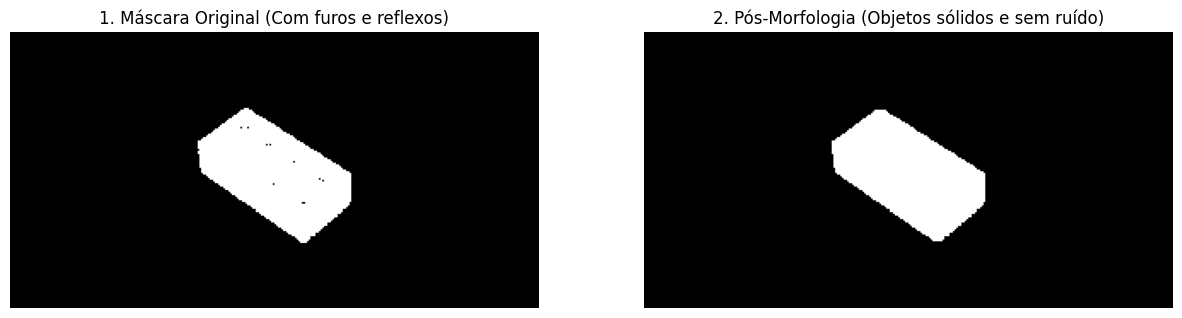

In [9]:
# ==============================================================================
# ETAPA 3: MORFOLOGIA MATEMÁTICA (TRATAMENTO DE RUÍDOS E FALHAS)
# ==============================================================================
# Esta célula limpa a imagem binária. Ela preenche buracos causados por reflexos
# ou furos e elimina poeira/ruídos do fundo para isolar perfeitamente as formas.
# ==============================================================================

# 1. DEFINIÇÃO DO ELEMENTO ESTRUTURANTE (KERNEL)
tamanho_kernel = 5
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (tamanho_kernel, tamanho_kernel))

# 2. APLICAÇÃO DO FECHAMENTO MORFOLÓGICO (CLOSING)
img_fechamento = cv2.morphologyEx(mascara_cor, cv2.MORPH_CLOSE, kernel)

# 3. APLICAÇÃO DA ABERTURA MORFOLÓGICA (OPENING)
# Aplicamos a abertura logo após o fechamento para garantir uma máscara limpa.
img_morfologia_limpa = cv2.morphologyEx(img_fechamento, cv2.MORPH_OPEN, kernel)

# 4. EXIBIÇÃO COMPARATIVA DOS RESULTADOS
# Vamos plotar o antes e o depois da morfologia.
plt.figure(figsize=(15, 6))

# Subplot 1: Máscara com falhas
plt.subplot(1, 2, 1)
plt.imshow(mascara_cor, cmap='gray')
plt.title("1. Máscara Original (Com furos e reflexos)")
plt.axis('off')

# Subplot 2: Máscara Limpa após Morfologia
plt.subplot(1, 2, 2)
plt.imshow(img_morfologia_limpa, cmap='gray')
plt.title("2. Pós-Morfologia (Objetos sólidos e sem ruído)")
plt.axis('off')

plt.show()

In [11]:
# ==============================================================================
# ETAPA 4: EXTRAÇÃO DE CONTORNOS E FILTRAGEM GEOMÉTRICA PROPORCIONAL À ÁREA DO OBJETO
# ==============================================================================
# Esta célula identifica os objetos e calcula a área de forma proporcional
# à área total ocupada por todos os objetos detectados, para lidar com
# variações de escala.
# ==============================================================================

# 1. ENCONTRAR TODOS OS CONTORNOS DA IMAGEM LIMPA
contornos, _ = cv2.findContours(img_morfologia_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 2. CALCULAR A ÁREA TOTAL DE TODOS OS OBJETOS DETECTADOS
area_total_objetos = 0
for cnt in contornos:
    area_total_objetos += cv2.contourArea(cnt)

# 3. DEFINIÇÃO DOS LIMITES PROPORCIONAIS (% DA ÁREA TOTAL DOS OBJETOS)
porcentagem_min = 0.0
porcentagem_max = 100.0

if "wire_clip" in peca_selecionada:
    porcentagem_min = 1.0  # Mínimo de 1% da área total dos objetos
    porcentagem_max = 5.0  # Máximo de 5% da área total dos objetos
elif "cross_axle" in peca_selecionada:
    porcentagem_min = 0.5
    porcentagem_max = 4.0
elif "brick_2x4" in peca_selecionada:
    porcentagem_min = 5.0
    porcentagem_max = 100.0
elif "technic_5m" in peca_selecionada:
    porcentagem_min = 3.0
    porcentagem_max = 15.0
elif "technic_11m" in peca_selecionada:
    porcentagem_min = 6.0
    porcentagem_max = 25.0
elif "biscuit" in peca_selecionada:
    # O biscuit é pequeno, ocupa uma pequena porcentagem da área total dos objetos
    porcentagem_min = 1.0
    porcentagem_max = 10.0

# Convertendo as porcentagens para valores reais de pixels baseados na área total dos objetos
limite_area_min = (porcentagem_min / 100.0) * area_total_objetos
limite_area_max = (porcentagem_max / 100.0) * area_total_objetos

# 4. FILTRAGEM DOS CONTORNOS E CONTAGEM
contornos_validos = []
contagem_pecas = 0

print(f"Área total ocupada pelos objetos detectados: {int(area_total_objetos)} pixels")
print(f"Limites calculados para o filtro: de {int(limite_area_min)} até {int(limite_area_max)} pixels.")
print("Analisando objetos encontrados na mesa...")
print("-" * 65)

for i, cnt in enumerate(contornos):
    # Calcula a área absoluta do contorno atual em pixels
    area = cv2.contourArea(cnt)

    # Filtro básico para ignorar pequenas sujeiras
    if area < 10:
        continue

    pct_ocupada = (area / area_total_objetos) * 100
    print(f"Objeto [{i+1}]: Área = {area:.1f} pixels ({pct_ocupada:.2f}% da área total dos objetos)")

    # Validação geométrica adaptativa
    if limite_area_min <= area <= limite_area_max:
        contornos_validos.append(cnt)
        contagem_pecas += 1
        print(f"   ->  [ACEITO]: Corresponde ao tamanho do {peca_selecionada}!")
    else:
        print(f"   ->  [REJEITADO]: Tamanho fora do esperado para esta peça nesta escala.")

print("-" * 65)
print(f"Total de peças do modelo '{peca_selecionada}' encontradas: {contagem_pecas}")
print("-" * 65)

Área total ocupada pelos objetos detectados: 3928 pixels
Limites calculados para o filtro: de 196 até 3928 pixels.
Analisando objetos encontrados na mesa...
-----------------------------------------------------------------
Objeto [1]: Área = 3928.5 pixels (100.00% da área total dos objetos)
   ->  [ACEITO]: Corresponde ao tamanho do brick_2x4_green!
-----------------------------------------------------------------
Total de peças do modelo 'brick_2x4_green' encontradas: 1
-----------------------------------------------------------------


             RELATÓRIO DE CONFERÊNCIA DO KIT LEGO             
 Peça analisada: brick_2x4_green
 Quantidade identificada na imagem: 1 unidade(s)
 Quantidade exigida pelo manual: 2 unidade(s)
-----------------------------------------------------------------
KIT INCOMPLETO! Faltam 1 peça(s) deste modelo.


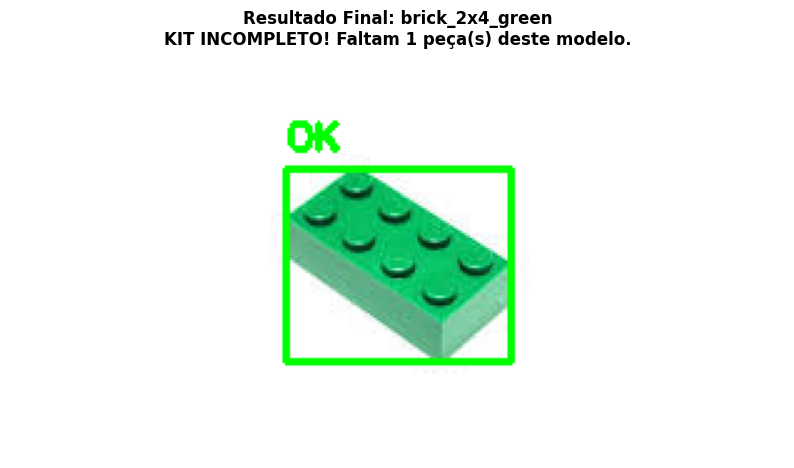

In [13]:
# ==============================================================================
# ETAPA 5: VALIDAÇÃO DO KIT E EXIBIÇÃO DO RESULTADO VISUAL FINAL
# ==============================================================================
# Esta célula calcula matematicamente o saldo de peças para o kit e gera
# a imagem final com as caixas de marcação (Bounding Boxes) e o veredito.
# ==============================================================================

# 1. CLONAR A IMAGEM ORIGINAL PARA DESENHAR O RESULTADO
img_resultado = img_original.copy()

# 2. DESENHAR OS RETÂNGULOS EM VOLTA DAS PEÇAS IDENTIFICADAS
for cnt in contornos_validos:
    # cv2.boundingRect calcula as coordenadas x, y, largura (w) e altura (h) do objeto
    x, y, w, h = cv2.boundingRect(cnt)

    # Desenha um retângulo verde (0, 255, 0) com espessura de 2 pixels ao redor da peça
    cv2.rectangle(img_resultado, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Escreve um pequeno texto "OK" logo acima da peça identificada
    cv2.putText(img_resultado, "OK", (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# 3. LÓGICA MATEMÁTICA DE VALIDAÇÃO DO KIT
# 'quantidade_alvo' veio da Etapa 1 (gabarito). 'contagem_pecas' veio da Etapa 4.
faltam = quantidade_alvo - contagem_pecas

print("=" * 65)
print("             RELATÓRIO DE CONFERÊNCIA DO KIT LEGO             ")
print("=" * 65)
print(f" Peça analisada: {peca_selecionada}")
print(f" Quantidade identificada na imagem: {contagem_pecas} unidade(s)")
print(f" Quantidade exigida pelo manual: {quantidade_alvo} unidade(s)")
print("-" * 65)

# Tomada de decisão e definição do texto de status
if faltam == 0:
    status_kit = "KIT COMPLETO para este modelo de peça!"
elif faltam > 0:
    status_kit = f"KIT INCOMPLETO! Faltam {faltam} peça(s) deste modelo."
else:
    status_kit = f"ATENÇÃO: Há {abs(faltam)} peça(s) SOBRANDO na mesa!"

print(status_kit)
print("=" * 65)

# 4. EXIBIÇÃO DO PAINEL VISUAL FINAL
# Convertendo de BGR para RGB para o Matplotlib renderizar as cores corretamente
img_resultado_rgb = cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(img_resultado_rgb)

# Adiciona o veredito do kit diretamente como título estilizado no gráfico
plt.title(f"Resultado Final: {peca_selecionada}\n{status_kit}",
          fontsize=12, color='black', weight='bold', backgroundcolor='white')

plt.axis('off')
plt.show()